## Along this course, we will fine tune on out-of-domain data, this is the data prep

* an area I am interested in in mice monitoring in home cages. This is a good domain for this task since it tends to be out of domain for a lot of VLMS. 

### Dataset: SLEAP Mouse Home Cage Monitoring

We use a SLEAP pose estimation dataset of mice in a home cage. 

The `.pkg.slp` format is a self-contained HDF5 archive with embedded video frames + pose annotations (keypoints per body part).

Source: https://sleap.ai

In [2]:
# !pip install sleap-io matplotlib

### 1. Download the SLEAP dataset

In [2]:
import urllib.request
from pathlib import Path

data_dir = Path("data")
data_dir.mkdir(exist_ok=True)

slp_path = data_dir / "train.pkg.slp"
url = "https://storage.googleapis.com/sleap-data/datasets/eleni_mice/random_split1/train.pkg.slp"

if not slp_path.exists():
    print("Downloading SLEAP dataset...")
    urllib.request.urlretrieve(url, slp_path)
    print(f"Downloaded to {slp_path} ({slp_path.stat().st_size / 1e6:.1f} MB)")
else:
    print(f"Already downloaded: {slp_path} ({slp_path.stat().st_size / 1e6:.1f} MB)")

Already downloaded: data/train.pkg.slp (696.5 MB)


### 2. Load and inspect the SLEAP annotations

In [3]:
import sleap_io as sio

labels = sio.load_slp(str(slp_path))

print(f"Videos:         {len(labels.videos)}")
print(f"Labeled frames: {len(labels.labeled_frames)}")
print(f"Skeletons:      {len(labels.skeletons)}")
print(f"Tracks:         {len(labels.tracks)}")

# Inspect the skeleton — what body parts are annotated?
skeleton = labels.skeletons[0]
print(f"\nBody parts ({len(skeleton.nodes)}): {[n.name for n in skeleton.nodes]}")
print(f"Edges: {[(e.source.name, e.destination.name) for e in skeleton.edges]}")

Videos:         40
Labeled frames: 1178
Skeletons:      1
Tracks:         98

Body parts (5): ['snout', 'earL', 'earR', 'tb', 'tt']
Edges: [('snout', 'earL'), ('snout', 'earR'), ('snout', 'tb'), ('tb', 'tt')]


In [4]:
import numpy as np
# Look at a single labeled frame in detail
lf = labels.labeled_frames[0]
print(f"Frame index: {lf.frame_idx}")                                                                                       
print(f"Number of instances (mice): {len(lf.instances)}")                                                                 
                                                                                                                            
for i, instance in enumerate(lf.instances):                                                                               
    print(f"\n  Mouse {i} (track: {instance.track})")
    pts = instance.numpy()  # (n_nodes, 2) array of x, y
    for node, pt in zip(skeleton.nodes, pts):
        if not np.isnan(pt[0]):
            print(f"    {node.name:>15s}: x={pt[0]:6.1f}, y={pt[1]:6.1f}")
        else:
            print(f"    {node.name:>15s}: not labeled")

Frame index: 5259
Number of instances (mice): 2

  Mouse 0 (track: None)
              snout: x= 554.0, y= 328.0
               earL: x= 586.0, y= 332.0
               earR: x= 590.0, y= 306.0
                 tb: x= 740.0, y= 352.0
                 tt: x= 874.9, y= 423.2

  Mouse 1 (track: None)
              snout: x= 392.0, y= 372.0
               earL: x= 444.1, y= 367.4
               earR: x= 433.1, y= 347.6
                 tb: x= 541.8, y= 324.9
                 tt: x= 705.1, y= 262.4


### 3. Extract frames and visualize with keypoints

In [5]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

def visualize_frame(lf, skeleton, ax=None):
    """Visualize a labeled frame with keypoints and skeleton edges."""
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    
    # Extract the image from the embedded video
    img = lf.video[lf.frame_idx]
    ax.imshow(img)
    
    colors = cm.tab10(np.linspace(0, 1, max(len(lf.instances), 1)))
    
    for i, instance in enumerate(lf.instances):
        pts = instance.numpy()  # (n_nodes, 2)
        color = colors[i]
        
        # Draw skeleton edges
        for edge in skeleton.edges:
            src_idx = skeleton.nodes.index(edge.source)
            dst_idx = skeleton.nodes.index(edge.destination)
            src_pt, dst_pt = pts[src_idx], pts[dst_idx]
            # Skip if either point is NaN (not labeled)
            if np.any(np.isnan(src_pt)) or np.any(np.isnan(dst_pt)):
                continue
            ax.plot([src_pt[0], dst_pt[0]], [src_pt[1], dst_pt[1]], 
                    c=color, linewidth=1.5, alpha=0.7)
        
        # Draw keypoints
        valid = ~np.isnan(pts[:, 0])
        ax.scatter(pts[valid, 0], pts[valid, 1], c=[color], s=25, 
                   zorder=5, edgecolors='white', linewidths=0.5)
        
        # Label the track
        if valid.any():
            first_valid = pts[valid][0]
            label = f"Mouse {i}" if instance.track is None else instance.track.name
            ax.text(first_valid[0], first_valid[1] - 10, label,
                    color=color, fontsize=8, fontweight='bold')
    
    ax.set_title(f"Frame {lf.frame_idx}")
    ax.axis('off')
    return ax

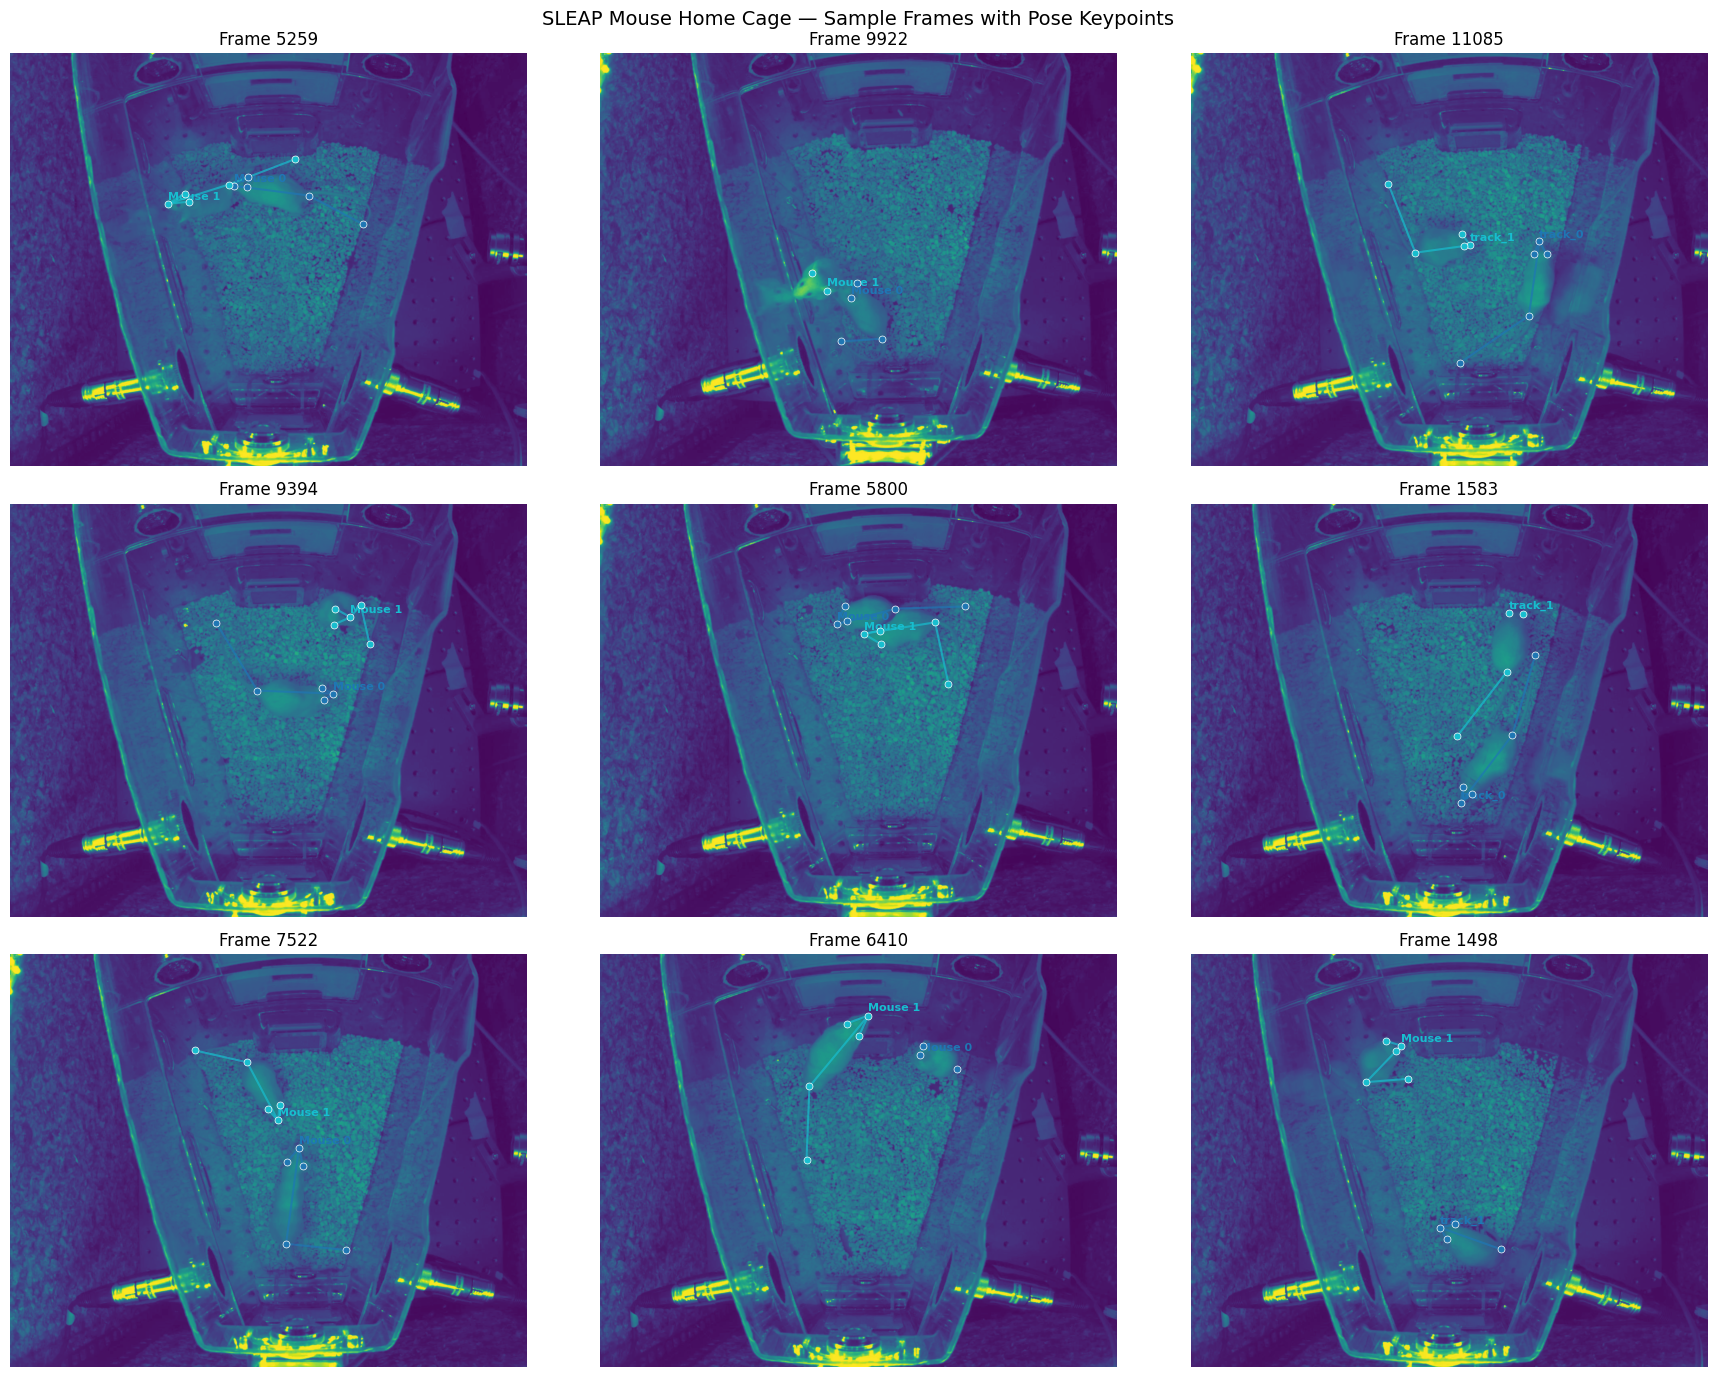

In [6]:
# Visualize a grid of sample frames
sample_indices = np.linspace(0, len(labels.labeled_frames) - 1, 9, dtype=int)

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
for ax, idx in zip(axes.flat, sample_indices):
    lf = labels.labeled_frames[idx]
    visualize_frame(lf, skeleton, ax=ax)

plt.suptitle("SLEAP Mouse Home Cage — Sample Frames with Pose Keypoints", fontsize=14)
plt.tight_layout()
plt.show()

### 4. Export frames as images + annotations summary

Save individual frames as PNGs and build a summary of the annotations for downstream VQA data generation.

In [7]:
data_dir

PosixPath('data')

In [8]:
import json                                                                                                                 
from PIL import Image                                                                                                       
                                                                                                                            
frames_dir = data_dir / "frames"                                                                                          
frames_dir.mkdir(exist_ok=True)                                                                                             
                                                    
# Check the shape of the video frames
sample_img = labels.labeled_frames[0].video[labels.labeled_frames[0].frame_idx]
print(f"Raw frame shape: {sample_img.shape}, dtype: {sample_img.dtype}")

annotations = []

for i, lf in enumerate(labels.labeled_frames):
    # Save frame as PNG
    img_array = lf.video[lf.frame_idx]
    # Squeeze extra dimensions (e.g. (1, H, W, 1) -> (H, W) or (1, H, W, 3) -> (H, W, 3))
    img_array = np.squeeze(img_array)
    img = Image.fromarray(img_array)
    img_path = frames_dir / f"frame_{i:04d}.png"
    img.save(img_path)

    # Build annotation record
    instances_data = []
    for inst in lf.instances:
        pts = inst.numpy()  # (n_nodes, 2)
        keypoints = {}
        for node, pt in zip(skeleton.nodes, pts):
            if not np.isnan(pt[0]):
                keypoints[node.name] = {"x": round(float(pt[0]), 1), "y": round(float(pt[1]), 1)}
        instances_data.append({
            "track": inst.track.name if inst.track else None,
            "keypoints": keypoints,
        })

    annotations.append({
        "frame_id": i,
        "frame_idx": lf.frame_idx,
        "image_path": str(img_path),
        "num_mice": len(lf.instances),
        "instances": instances_data,
    })

# Save annotations
ann_path = data_dir / "annotations.json"
with open(ann_path, "w") as f:
    json.dump(annotations, f, indent=2)

print(f"Exported {len(annotations)} frames to {frames_dir}")
print(f"Annotations saved to {ann_path}")
print(f"\nSample annotation:")
print(json.dumps(annotations[0], indent=2))

Raw frame shape: (1024, 1280, 1), dtype: uint8
Exported 1178 frames to data/frames
Annotations saved to data/annotations.json

Sample annotation:
{
  "frame_id": 0,
  "frame_idx": 5259,
  "image_path": "data/frames/frame_0000.png",
  "num_mice": 2,
  "instances": [
    {
      "track": null,
      "keypoints": {
        "snout": {
          "x": 554.0,
          "y": 328.0
        },
        "earL": {
          "x": 586.0,
          "y": 332.0
        },
        "earR": {
          "x": 590.0,
          "y": 306.0
        },
        "tb": {
          "x": 740.0,
          "y": 352.0
        },
        "tt": {
          "x": 874.9,
          "y": 423.2
        }
      }
    },
    {
      "track": null,
      "keypoints": {
        "snout": {
          "x": 392.0,
          "y": 372.0
        },
        "earL": {
          "x": 444.1,
          "y": 367.4
        },
        "earR": {
          "x": 433.1,
          "y": 347.6
        },
        "tb": {
          "x": 541.8,
          "y

### 6. Generate VQA training pairs from annotations

We programmatically create question-answer pairs from the keypoint data. The goal is to teach the VLM domain-specific vocabulary and spatial precision — things like body part names, posture descriptions, inter-mouse distances, and occlusion awareness.

**Question categories:**
1. **Counting** — "How many mice are in this frame?"
2. **Localization** — "Where is Mouse A's snout?"
3. **Body part visibility** — "Which body parts are visible/occluded?"
4. **Posture** — computed from snout-to-tail geometry
5. **Spatial relationships** — inter-mouse distance, relative positions
6. **Orientation** — which direction is the mouse facing?

In [10]:
import random

# Readable names for body parts
PART_NAMES = {
    "snout": "snout",
    "earL": "left ear",
    "earR": "right ear",
    "tb": "tail base",
    "tt": "tail tip",
}

# Image dimensions (from our earlier inspection)
IMG_W, IMG_H = 1280, 1024

def get_centroid(kps):
    """Get the centroid of all visible keypoints."""
    xs = [v["x"] for v in kps.values()]
    ys = [v["y"] for v in kps.values()]
    return np.mean(xs), np.mean(ys)

def get_spatial_label(kps, all_centroids):
    """Generate a natural spatial description for a mouse based on its position.
    
    For single-mouse frames: 'the mouse'
    For multi-mouse frames: uses relative position like 'the mouse on the left',
    'the mouse near the top-right', etc.
    """
    if len(all_centroids) == 1:
        return "the mouse"
    
    cx, cy = get_centroid(kps)
    
    # Determine horizontal position
    x_frac = cx / IMG_W
    if x_frac < 0.33:
        h_pos = "left"
    elif x_frac > 0.66:
        h_pos = "right"
    else:
        h_pos = "center"
    
    # Determine vertical position
    y_frac = cy / IMG_H
    if y_frac < 0.33:
        v_pos = "top"
    elif y_frac > 0.66:
        v_pos = "bottom"
    else:
        v_pos = "middle"
    
    # Combine into a natural label
    if v_pos == "middle" and h_pos == "center":
        # Fall back to relative comparison with other mice
        other_cx = [c[0] for c in all_centroids if c != (cx, cy)]
        if other_cx and cx < min(other_cx):
            return "the mouse on the left"
        elif other_cx and cx > max(other_cx):
            return "the mouse on the right"
        return "the mouse in the center"
    elif v_pos == "middle":
        return f"the mouse on the {h_pos}"
    elif h_pos == "center":
        return f"the mouse near the {v_pos}"
    else:
        return f"the mouse near the {v_pos}-{h_pos}"

def get_body_length(kps):
    """Euclidean distance from snout to tail tip (if both visible)."""
    if "snout" in kps and "tt" in kps:
        dx = kps["tt"]["x"] - kps["snout"]["x"]
        dy = kps["tt"]["y"] - kps["snout"]["y"]
        return np.sqrt(dx**2 + dy**2)
    return None

def get_heading(kps):
    """Direction mouse is facing based on snout → tail base vector (reversed)."""
    if "snout" in kps and "tb" in kps:
        dx = kps["snout"]["x"] - kps["tb"]["x"]
        dy = kps["snout"]["y"] - kps["tb"]["y"]
        angle = np.degrees(np.arctan2(-dy, dx))  # image y is inverted
        if -45 <= angle < 45:
            return "right"
        elif 45 <= angle < 135:
            return "upward"
        elif -135 <= angle < -45:
            return "downward"
        else:
            return "left"
    return None

def get_posture(kps):
    """Estimate posture from keypoint geometry."""
    length = get_body_length(kps)
    if length is None:
        return None
    if "snout" in kps and "tb" in kps:
        dx = kps["tb"]["x"] - kps["snout"]["x"]
        dy = kps["tb"]["y"] - kps["snout"]["y"]
        body_len = np.sqrt(dx**2 + dy**2)
        ratio = body_len / length if length > 0 else 0
        if ratio < 0.45:
            return "curled up"
        elif ratio < 0.65:
            return "hunched"
        else:
            return "stretched or locomoting"
    return None

print("Helper functions defined.")

Helper functions defined.


In [11]:
def generate_qa_pairs(ann):
    """Generate multiple VQA pairs from a single frame annotation."""
    qa_pairs = []
    instances = ann["instances"]
    num_mice = ann["num_mice"]
    
    # Pre-compute centroids and spatial labels for all mice
    all_centroids = []
    for inst in instances:
        kps = inst["keypoints"]
        if kps:
            all_centroids.append(get_centroid(kps))
        else:
            all_centroids.append((0, 0))
    
    labels = []
    for inst in instances:
        kps = inst["keypoints"]
        if kps:
            labels.append(get_spatial_label(kps, all_centroids))
        else:
            labels.append("a mouse")
    
    # --- 1. Counting ---
    qa_pairs.append({
        "question": "How many mice are visible in this image?",
        "answer": f"There {'is' if num_mice == 1 else 'are'} {num_mice} {'mouse' if num_mice == 1 else 'mice'} visible in this image."
    })
    
    # --- 2. Localization (per mouse) ---
    for i, inst in enumerate(instances):
        kps = inst["keypoints"]
        label = labels[i]
        
        if len(kps) == 0:
            continue
        
        cx, cy = get_centroid(kps)
        qa_pairs.append({
            "question": f"Where is {label} located in the image?",
            "answer": f"{label.capitalize()} is centered at approximately ({cx:.0f}, {cy:.0f}) in pixel coordinates."
        })
        
        # Specific body part location (pick a random visible one)
        part = random.choice(list(kps.keys()))
        readable = PART_NAMES[part]
        qa_pairs.append({
            "question": f"Where is the {readable} of {label}?",
            "answer": f"The {readable} of {label} is at pixel coordinates ({kps[part]['x']:.0f}, {kps[part]['y']:.0f})."
        })
    
    # --- 3. Body part visibility ---
    for i, inst in enumerate(instances):
        kps = inst["keypoints"]
        label = labels[i]
        visible = [PART_NAMES[k] for k in kps.keys()]
        all_parts = set(PART_NAMES.keys())
        occluded = [PART_NAMES[k] for k in all_parts - set(kps.keys())]
        
        if occluded:
            qa_pairs.append({
                "question": f"Which body parts of {label} are occluded or not visible?",
                "answer": f"The following body parts of {label} are not visible: {', '.join(occluded)}. "
                          f"Visible parts are: {', '.join(visible)}."
            })
        else:
            qa_pairs.append({
                "question": f"Are all body parts of {label} visible?",
                "answer": f"Yes, all tracked body parts of {label} are visible: {', '.join(visible)}."
            })
    
    # --- 4. Posture ---
    for i, inst in enumerate(instances):
        kps = inst["keypoints"]
        label = labels[i]
        posture = get_posture(kps)
        if posture:
            length = get_body_length(kps)
            qa_pairs.append({
                "question": f"Describe the posture of {label}.",
                "answer": f"{label.capitalize()} appears to be {posture}. "
                          f"The snout-to-tail-tip distance is approximately {length:.0f} pixels."
            })
    
    # --- 5. Orientation ---
    for i, inst in enumerate(instances):
        kps = inst["keypoints"]
        label = labels[i]
        heading = get_heading(kps)
        if heading:
            qa_pairs.append({
                "question": f"Which direction is {label} facing?",
                "answer": f"{label.capitalize()} is facing {heading}, based on the snout-to-tail-base axis."
            })
    
    # --- 6. Spatial relationships (if 2+ mice) ---
    if num_mice >= 2:
        for i in range(len(instances)):
            for j in range(i + 1, len(instances)):
                kps_i = instances[i]["keypoints"]
                kps_j = instances[j]["keypoints"]
                if "snout" in kps_i and "snout" in kps_j:
                    dx = kps_i["snout"]["x"] - kps_j["snout"]["x"]
                    dy = kps_i["snout"]["y"] - kps_j["snout"]["y"]
                    dist = np.sqrt(dx**2 + dy**2)
                    label_i, label_j = labels[i], labels[j]
                    
                    proximity = "close together (possible social interaction)" if dist < 150 else \
                                "at moderate distance" if dist < 400 else "far apart"
                    
                    qa_pairs.append({
                        "question": f"How far apart are the two mice?",
                        "answer": f"The snout-to-snout distance between {label_i} and {label_j} "
                                  f"is approximately {dist:.0f} pixels. They are {proximity}."
                    })
    
    return qa_pairs

# Generate for all frames
random.seed(42)
all_vqa = []
for ann in annotations:
    pairs = generate_qa_pairs(ann)
    for qa in pairs:
        all_vqa.append({
            "image": ann["image_path"],
            "frame_id": ann["frame_id"],
            "question": qa["question"],
            "answer": qa["answer"],
        })

print(f"Generated {len(all_vqa)} VQA pairs from {len(annotations)} frames")
print(f"Average {len(all_vqa)/len(annotations):.1f} questions per frame")

Generated 12987 VQA pairs from 1178 frames
Average 11.0 questions per frame


In [12]:
# Preview some examples
random.seed(42)
samples = random.sample(all_vqa, 10)
for s in samples:
    print(f"[Frame {s['frame_id']}]")
    print(f"  Q: {s['question']}")
    print(f"  A: {s['answer']}")
    print()

[Frame 950]
  Q: Which direction is the mouse near the top facing?
  A: The mouse near the top is facing right, based on the snout-to-tail-base axis.

[Frame 166]
  Q: Where is the mouse near the bottom located in the image?
  A: The mouse near the bottom is centered at approximately (616, 802) in pixel coordinates.

[Frame 37]
  Q: Which direction is the mouse near the bottom facing?
  A: The mouse near the bottom is facing left, based on the snout-to-tail-base axis.

[Frame 1102]
  Q: How many mice are visible in this image?
  A: There are 2 mice visible in this image.

[Frame 410]
  Q: How far apart are the two mice?
  A: The snout-to-snout distance between the mouse near the top and the mouse near the top is approximately 168 pixels. They are at moderate distance.

[Frame 367]
  Q: Where is the left ear of the mouse near the bottom?
  A: The left ear of the mouse near the bottom is at pixel coordinates (784, 853).

[Frame 335]
  Q: Are all body parts of the mouse near the top visib

### 7. Save VQA dataset and train/val split

In [13]:
# Split by frame (not by QA pair) to avoid data leakage
frame_ids = list(set(s["frame_id"] for s in all_vqa))
random.seed(42)
random.shuffle(frame_ids)

split_idx = int(0.85 * len(frame_ids))
train_frames = set(frame_ids[:split_idx])
val_frames = set(frame_ids[split_idx:])

train_vqa = [s for s in all_vqa if s["frame_id"] in train_frames]
val_vqa = [s for s in all_vqa if s["frame_id"] in val_frames]

print(f"Train: {len(train_vqa)} QA pairs ({len(train_frames)} frames)")
print(f"Val:   {len(val_vqa)} QA pairs ({len(val_frames)} frames)")

# Save
vqa_dir = data_dir / "vqa"
vqa_dir.mkdir(exist_ok=True)

with open(vqa_dir / "train.json", "w") as f:
    json.dump(train_vqa, f, indent=2)

with open(vqa_dir / "val.json", "w") as f:
    json.dump(val_vqa, f, indent=2)

# Also save the full dataset
with open(vqa_dir / "all.json", "w") as f:
    json.dump(all_vqa, f, indent=2)

print(f"\nSaved to {vqa_dir}/")

# Question type distribution
from collections import Counter
q_types = []
for s in all_vqa:
    q = s["question"]
    if "How many" in q:
        q_types.append("counting")
    elif "Where is Mouse" in q and "located" in q:
        q_types.append("mouse location")
    elif "Where is the" in q:
        q_types.append("body part location")
    elif "occluded" in q or "visible" in q:
        q_types.append("visibility")
    elif "posture" in q:
        q_types.append("posture")
    elif "direction" in q:
        q_types.append("orientation")
    elif "far apart" in q:
        q_types.append("spatial relationship")
    else:
        q_types.append("other")

counts = Counter(q_types)
print("\nQuestion type distribution:")
for qtype, count in counts.most_common():
    print(f"  {qtype:>25s}: {count:5d} ({count/len(all_vqa)*100:.1f}%)")

Train: 11011 QA pairs (1001 frames)
Val:   1976 QA pairs (177 frames)

Saved to data/vqa/

Question type distribution:
         body part location:  4712 (36.3%)
                 visibility:  2356 (18.1%)
                orientation:  2003 (15.4%)
                    posture:  1831 (14.1%)
                   counting:  1178 (9.1%)
       spatial relationship:   907 (7.0%)
